In [7]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.signal import fftconvolve

psf_path = 'psf_used.tif'
image_path = 'org_MoS2.tif'
iteration = 100
eps = 1e-12
noise_level = 10
output_crop_fraction = 0.05
rms_center_fraction = 0.50
output_dir = 'example_deconvolution_results'
iteration_tif_dir = os.path.join(output_dir, 'rl_iteration_tif')
os.makedirs(iteration_tif_dir, exist_ok=True)


In [8]:
def read_gray(path):
    image = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if image is None:
        raise FileNotFoundError(path)
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if image.ndim == 3 else image

def load_psf(path):
    ext = os.path.splitext(path)[1].lower()
    psf = np.load(path) if ext == '.npy' else np.loadtxt(path) if ext == '.txt' else read_gray(path)
    psf = np.maximum(np.asarray(psf, np.float64), 0.0)
    return psf / psf.sum()

def correlate_same(image, kernel):
    return fftconvolve(image, kernel[::-1, ::-1], mode='same')

def center_roi(image, fraction):
    h, w = image.shape
    rh, rw = max(1, round(h * fraction)), max(1, round(w * fraction))
    y, x = (h - rh) // 2, (w - rw) // 2
    return image[y:y + rh, x:x + rw]

def rms_difference(current, initial):
    difference = center_roi(current, rms_center_fraction) - center_roi(initial, rms_center_fraction)
    return np.sqrt(np.mean(difference ** 2))

def save_tif(path, image):
    h, w = image.shape
    cy, cx = int(np.floor(h * output_crop_fraction)), int(np.floor(w * output_crop_fraction))
    cropped = image[cy:h - cy if cy else h, cx:w - cx if cx else w].copy()
    hc, wc = cropped.shape
    ref = cropped[hc // 4:hc - hc // 4, wc // 4:wc - wc // 4]
    vmin, vmax = ref.min(), ref.max()
    view = (cropped - vmin) / (vmax - vmin) if vmax > vmin else np.zeros_like(cropped)
    cv2.imwrite(path, np.clip(view * 65535.0, 0, 65535).astype(np.uint16))
    return cropped


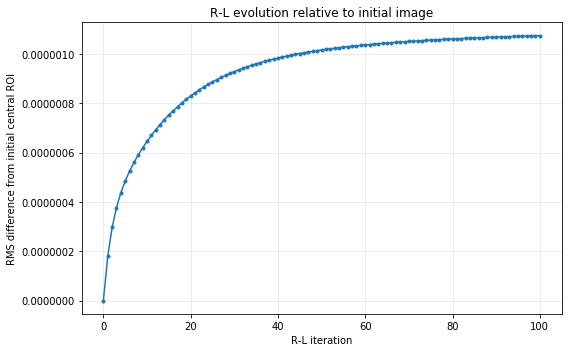

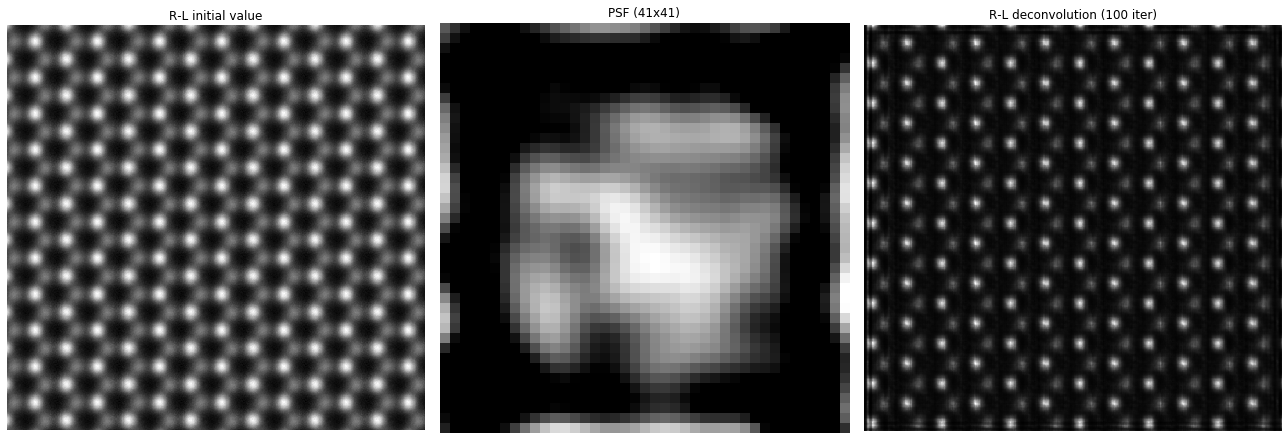

Final RMS: 1.0736110963e-06
Saved: example_deconvolution_results\example_deconvolution_100iter_crop10pct.tif
Saved: example_deconvolution_results\RMS_vs_RL_iteration.png


In [9]:
psf = load_psf(psf_path)
image = np.asarray(read_gray(image_path), np.float64)
image /= image.max()
background_min = fftconvolve(image, np.ones((noise_level, noise_level)), mode='valid').min() / noise_level ** 2
image = image + background_min
image /= image.sum()

dcv = image.copy()
initial = dcv.copy()
psf_flip = psf[::-1, ::-1]
rms_history = [0.0]
save_tif(os.path.join(iteration_tif_dir, 'rl_iteration_000.tif'), dcv)

for i in range(1, iteration + 1):
    estimated = correlate_same(dcv, psf)
    dcv *= correlate_same(image / (estimated + eps), psf_flip)
    rms_history.append(rms_difference(dcv, initial))
    save_tif(os.path.join(iteration_tif_dir, f'rl_iteration_{i:03d}.tif'), dcv)

rms_history = np.asarray(rms_history)
final_tif = os.path.join(output_dir, f'example_deconvolution_{iteration}iter_crop10pct.tif')
deconvolved_cropped = save_tif(final_tif, dcv)
np.save(os.path.join(output_dir, f'example_deconvolution_{iteration}iter_full.npy'), dcv)
np.savetxt(os.path.join(output_dir, f'example_deconvolution_{iteration}iter_crop10pct.txt'), deconvolved_cropped, fmt='%.10e')
np.savetxt(os.path.join(output_dir, 'RMS_vs_RL_iteration.txt'), np.column_stack((np.arange(iteration + 1), rms_history)), header='RL_iteration  RMS', fmt=['%d', '%.10e'])
np.save(os.path.join(output_dir, 'RMS_vs_RL_iteration.npy'), rms_history)

plt.figure(figsize=(8, 5))
plt.plot(np.arange(iteration + 1), rms_history, marker='o', markersize=3)
plt.xlabel('R-L iteration')
plt.ylabel('RMS difference from initial central ROI')
plt.title('R-L evolution relative to initial image')
plt.grid(True, alpha=0.3)
plt.tight_layout()
rms_graph_path = os.path.join(output_dir, 'RMS_vs_RL_iteration.png')
plt.savefig(rms_graph_path, dpi=300, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(1, 3, figsize=(18, 6))
ax[0].imshow(image, cmap='gray'); ax[0].set_title('R-L initial value')
ax[1].imshow(psf, cmap='gray'); ax[1].set_title(f'PSF ({psf.shape[0]}x{psf.shape[0]})')
ax[2].imshow(deconvolved_cropped, cmap='gray'); ax[2].set_title(f'R-L deconvolution ({iteration} iter)')
for a in ax: a.axis('off')
plt.tight_layout()
plt.show()

print(f'Final RMS: {rms_history[-1]:.10e}')
print(f'Saved: {final_tif}')
print(f'Saved: {rms_graph_path}')
